In [1]:
%matplotlib notebook
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time
from collections import deque
import re
from IPython.display import display, clear_output
from epics import caget, caget_many
import os
import pandas as pd
import pickle
from datetime import datetime

In [2]:
import sys
path_to_BPMQ_package = ".."
sys.path.append(os.path.join(path_to_BPMQ_package,'BPMQ/models'))
from BPMQ_model import raw2Q_processor
from TIS161_coeffs import TIS161_coeffs

In [3]:
update_interval = 0.2  # seconds
averaging_time = 10.0  # seconds for averaging
reference_beamQ_file = '[BPMQ_df]20250419_0302_48Ca(20,19)_215MeV_20kW.h5'
plot_difference = True

In [4]:
BPM_names = [
    'LS3_BTS:BPM_D4753',
    'LS3_BTS:BPM_D4769',
    'LS3_BTS:BPM_D4843',
    'LS3_BTS:BPM_D4886',
    'LS3_BTS:BPM_D4968',
    'LS3_BTS:BPM_D5010',
    'LS3_BTS:BPM_D5092',
    'LS3_BTS:BPM_D5134',
    'LS3_BTS:BPM_D5216',
    'LS3_BTS:BPM_D5259',
    'LS3_BTS:BPM_D5340',
    'LS3_BTS:BPM_D5381',
    'LS3_BTS:BPM_D5430',
    'LS3_BTS:BPM_D5445',
    'BDS_BTS:BPM_D5499',
    'BDS_BTS:BPM_D5513',
    'BDS_BTS:BPM_D5565',
]
x_axis_vals = [1e-2*int(re.search(r'D(\d{4})', pv).group(1)) for pv in BPM_names]
x_axis_labels = [re.search(r'(BPM_D\d{4})', item).group(1) for item in BPM_names]
raw2Q = raw2Q_processor(BPM_names=BPM_names, model_type='TIS161_GP')
BPMQ_names = [f'{bpm}:beamQ' for bpm in BPM_names]

In [5]:
def get_reference_beamQ(reference_beamQ_file):
    if '.pkl' in reference_beamQ_file:
        df = pickle.load(open(reference_beamQ_file,'rb'))
        if type(df) == dict:
            df = pd.DataFrame(df)
            if df.columns[0] == 0:
                df = pd.DataFrame(df['mean']).T
    elif '.h5' in reference_beamQ_file:
        df = pd.read_hdf(reference_beamQ_file)
    return df

In [6]:
reference_df = get_reference_beamQ(reference_beamQ_file)
reference_df = raw2Q(reference_df)
reference_beamQ = reference_df[BPMQ_names].values[0]

In [7]:
all_BPM_names = list(TIS161_coeffs.keys())
list_of_pvs = []
for bpm in all_BPM_names:
    list_of_pvs += [bpm+':XPOS_RD',bpm+':YPOS_RD',bpm+':MAG_RD']
    list_of_pvs += [bpm+f':TISMAG161_{i}_RD' for i in [1,2,3,4]]

In [8]:
class fetch_data_cls:
    def __init__(self):
        max_points = int(averaging_time / update_interval)  # Number of points to average
        self.data_history = deque(maxlen=max_points)  # Stores recent data arrays

    def __call__(self):
        while True:
            try:
                data_array = caget_many(list_of_pvs)
                break
            except Exception as e:
                print(f"Error fetching data: {e}")
                time.sleep(update_interval)
                continue
            
        self.data_history.append(data_array)
        if len(self.data_history) > 0:
            ave_data_history = np.mean(list(self.data_history), axis=0)
        else:
            ave_data_history = data_array
            
        df = pd.DataFrame(ave_data_history, index = list_of_pvs).T
        self.df = raw2Q(df)
        beamQ = self.df[BPMQ_names].values[0]
        return beamQ
    
    def get_all_data(self):
        df = pd.DataFrame(self.data_history, columns = list_of_pvs)
        return raw2Q(df)
    
    def save(self,fname):
        df = self.get_all_data()
        if fname[-3]!=".h5":
            fname = fname + ".h5"
        df.to_hdf(fname,key='BPMQ_LivePlot')
    
fetch_data = fetch_data_cls()

# plot

<IPython.core.display.Javascript object>


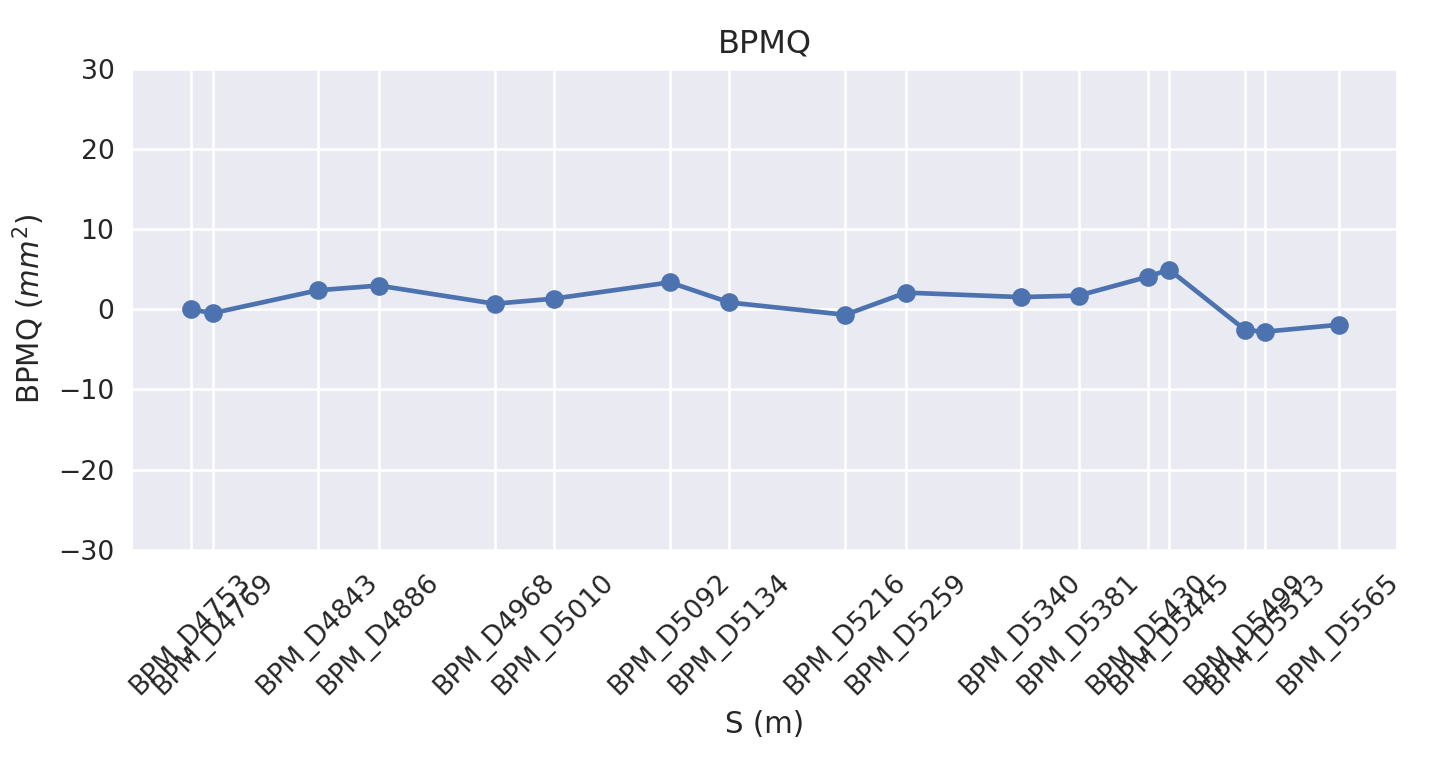

In [9]:
beamQ = fetch_data()
if plot_difference:
    y_axis_vals = beamQ - reference_beamQ
else:
    y_axis_vals = beamQ

plt.style.use('seaborn-v0_8')  # Updated to avoid deprecation warning
fig, ax = plt.subplots(figsize=(7.5, 4),dpi=128)
line, = ax.plot(x_axis_vals, y_axis_vals,  'o-')
ax.set_xlabel('S (m)')
ax.set_ylabel('BPMQ $(mm^2)$')
ax.set_title('BPMQ')
# ax.legend()
ax.grid(True)
ax.set_xticks(x_axis_vals)  # Set x-ticks to exact locations
ax.set_xticklabels(x_axis_labels, rotation=45)  # Rotate labels for readability

def init():
    ax.set_ylim(-30,30)
    return [line]

def update(frame):
    beamQ = fetch_data()
    if plot_difference:
        y_axis_vals = beamQ - reference_beamQ
    else:
        y_axis_vals = beamQ
    line.set_ydata(y_axis_vals)
    return [line]


ani = FuncAnimation(fig, update,init_func=init, interval=update_interval*1000, blit=True)
plt.tight_layout()
plt.show()

In [12]:
E_MeVu = 215
Charge_number = 20

SCS = caget("ACS_DIAG:DEST:ACTIVE_ION_SOURCE")
Mass_number = caget("FE_ISRC"+str(SCS)+":BEAM:A_BOOK")
Ion = caget("FE_ISRC"+str(SCS)+":BEAM:ELMT_BOOK")

In [13]:
# fname = '[BPMQ_df]'+datetime.now().strftime('%Y%m%d_%H%M')+f'_{Mass_number}{Ion}{Charge_number}+_{E_MeVu}MeV'
fname = '[BPMQ_df]'+datetime.now().strftime('%Y%m%d_%H%M')+f'_{Mass_number}{Ion}(20,19)_{E_MeVu}MeV_20kW'
print(fname)
fetch_data.save(fname)

[BPMQ_df]20250419_0302_48Ca(20,19)_215MeV_20kW
